In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy
from sympy import *

## Задачі
$\newcommand{\ket}[1]{\left.\left\vert\, #1\,\right. \right \rangle}$
$\newcommand{\bra}[1]{\left. \langle \, #1\, \right\vert}$
$\newcommand{\braket}[2]{\langle \,#1 \vert #2 \, \rangle}$
$\newcommand{\av}[3]{\left\langle \,#1 \left \vert\, #2 \,\right\vert #3 \,\right \rangle}$


__<a id='inftywell'>Задача</a>__
Визначте спектр стаціонарних станів частинки у $\infty$--глибокій потенціальній ямі $x \in [0,a]$ з граничними
умовами:
$$
  \psi(0) = \psi(a) = 0\,.
$$
<br>

__Розв'язок__ Рівняння Шредінгера в даному випадку є простим диференційним рівнянням. Накладаючи граничні умови дістаємо відповідь:
$$
-\frac{d^2}{d\,x^2}\psi = k^2\,\psi\,,\quad k^2 = \frac{2\,m\,E}{\hbar^2}\,,\\
\psi(x) = C\,\sin{k_{n}\,x}\,,\quad C= \sqrt{\frac{2}{a}}\,,\,\,\,\,
 k_{n} = \frac{\pi\,n}{a}\,,\,\, n \in
\mathbb{Z}\\
E_{n} = \frac{\hbar^2\,\pi^2}{2\,m\,a^2}\,n^2
$$
Очевидна повна аналогія із задачею з курсу ММФ про коливання дроту із закріпленими кінцями.
***

In [ ]:
psi,f,f0 = symbols('psi f f0',cls=Function)
x,a = symbols('x a',real=True)
k = Symbol('k',positive=True)
#
diffeq=Eq(diff(f(x),x,2),-k**2*f(x))
sol0=dsolve(diffeq,f(x),ics={f(0):0})
sol0

Eq(f(x), C1*sin(k*x))

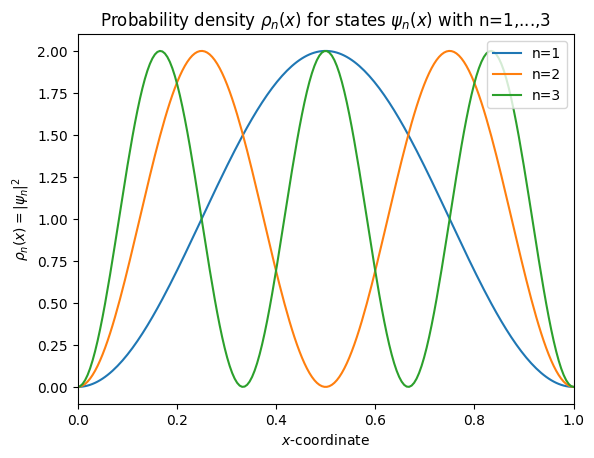

In [ ]:
# Silly example data
bp_x = np.linspace(0, 1, num=200, endpoint=True)
#
n0=3 # number of states
#
psiarr = [np.sqrt(2)*np.sin((i+1)*np.pi*bp_x) for i in range(n0)]
#
fig, ax = plt.subplots()
for i in range(n0):
    ax.plot(bp_x, psiarr[i]**2,'C'+str(i),label=r'n='+str(i+1))
#
plt.xlabel(r"$x$-coordinate")
plt.ylabel(r"$\rho_{n}(x)=|\psi_{n}|^2$")
plt.title(r"Probability density $\rho_{n}(x)$ for states $\psi_{n}(x)$ with n=1,...,"
          +str(n0))
plt.xlim(0, 1.)
plt.ylim(-0.1, 2.1)
plt.legend(loc="upper right")
plt.show()

__Задача__ Знайдіть енергетчний спектр і хвильові функції стаціонарних
станів у координатному представленії для одномерного квантового
осциллятора:
$$
\hat{H} = \frac{\hat{p}^2}{2\,m}+\frac{m\,\omega^2}{2}\,\hat{x}^2\,.
$$<br>
__Рішення__
Рівняння Шредінгера може бути переписано в
наступному вигляді:

\begin{align}
  \frac{d^2\,\psi}{d\, \xi^2} + (\varepsilon-\xi^2)\psi = 0\,.\label{osc_shrod_xi}\\
  \xi = x/x_0\,,\quad x_0^2 = \frac{\hbar}{m\,\omega}\,,\quad \varepsilon =
  \frac{2\,E}{\hbar\,\omega}\label{x0p0}
\end{align}

Оскільки асиптотично, при $\xi \to \infty$, \eqref{osc_shrod_xi}
зводиться до

\begin{equation}\label{xia}
  \frac{d^2\,\psi}{d\, \xi^2} -\xi^2\psi = 0
\end{equation}

Рішення доцільно шукати у вигляді:

$$\psi(\xi) = \exp\left(-\frac{\xi^2}{2}\right)\, f(\xi)\,,$$

Оскільки:

$$\psi''(\xi) = \exp\left(-\frac{\xi^2}{2}\right)\,
(f''(\xi)+\xi^2\,f(\xi)-2\,\xi\,f'(\xi)-f(\xi))\,.$$

підставляючи
це вираз у \eqref{osc_shrod_xi}, отримуємо:

\begin{equation}\label{xi1}
  f''-2\,\xi\,f'(\xi)+(\varepsilon - 1)\,f(\xi)=0\,
\end{equation}

Рішення \eqref{xi1} будем шукати у вигляді ряда:

\begin{equation}\label{ser}
  f(\xi) = \sum\limits_{n=0}^{\infty} a_n\,\xi^n\,.
\end{equation}

підставляючи \eqref{ser} у \eqref{xi1} отримаємо рівняння для
коэффициентов $a_n$:

\begin{equation}\label{an}
  a_{n+2} = \frac{2\,n+1-\epsilon}{(n+2)(n+1)}\,a_n
\end{equation}

Асимптотично, при $n\to \infty$ з \eqref{an} витікає що:
\begin{equation}\label{anas}
  a_{n+2} = \frac{2}{n}\,a_n\,,
\end{equation}
Це відповідає розкладу функції $\exp(\xi^2)$\,. Тобто якщо
ряд \eqref{ser} не обірветься, ми не отримаємо нормоване рішення.
Значення параметру $\varepsilon$, при яких функція $f$ є
многочленом дорівнюють $\varepsilon = 2\,n+1$, з чого виводимо рівні
энергії одномірного осцилятора:
$$
E_n = \hbar\,\omega\,\left(n+\frac{1}{2}\right)\,.$$
<a id='wfosc'>Хвильові функції відповідних стаціонарних станів мають вигляд</a>:
<!--  -->
\begin{equation}\label{wfn}
\psi_{n}(\xi) =
C_{n}\,H_{n}(\xi)\,\exp\left(-\frac{\xi^2}{2}\right)\,,
\end{equation}
<!--  -->
тут
$$
H_n(-x) = (-1)^n\,H_n(x)
$$
где $H_{n}$ - т.з. поліноми Ерміта. Як витікає з попереднього вони задовільняють <a id='herniteq'>рівнянню</a>:
$$ \frac{d^2 H_n}{d x^2}-2\,x\,\frac{d H_n}{dx}+2\,n\,H_n=0\,.$$
***

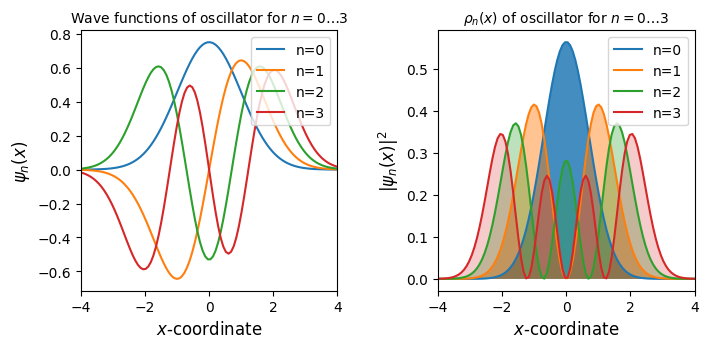

In [ ]:
from scipy import special
from scipy.special import factorial
x0,n0=4,4
#
xosc=np.linspace(-x0, x0, num=100, endpoint=True)
wvpsiosc = [1/(np.sqrt(2**i*np.sqrt(np.pi)*factorial(i, exact=True)))*special.hermite(i)(xosc)*np.exp(-xosc**2/2) for i in range(n0)]
#
psi2osc = [wvpsiosc[i]**2 for i in range(n0)]
#
fig, ax = plt.subplots(nrows=1,ncols=2,layout='constrained',figsize=(7,3.4))
#
for i in range(n0):
    y=wvpsiosc[i]
    ax[0].plot(xosc, y, 'C'+str(i),label=r'n='+str(i))
    #
ax[0].set_xlabel(r"$x$-coordinate",size=12)
ax[0].set_ylabel(r"$\psi_{n}(x)$",size=12)
ax[0].set_title(r"Wave functions of oscillator for $n=0\ldots$"+str(n0-1),size=10)
ax[0].set_xlim(-x0, x0)
# plt.ylim(-0.1, 0.6)
ax[0].legend(loc="upper right")
#
for i in range(n0):
    y=psi2osc[i]
    ax[1].fill_between(xosc,y, alpha=1/(i+1.2))
    ax[1].plot(xosc, y, 'C'+str(i),label=r'n='+str(i))
  #
ax[1].set_xlabel(r"$x$-coordinate",size=12)
ax[1].set_ylabel(r"$\vert\psi_{n}(x)\vert^2$",size=12)
ax[1].set_title(r"$\rho_{n}(x)$ of oscillator for $n=0\ldots$"+str(n0-1),size=10)
ax[1].set_xlim(-x0, x0)
# plt.ylim(-0.1, 0.6)
ax[1].legend(loc="upper right")
#
fig.get_layout_engine().set(w_pad=4/72, h_pad=4/72, hspace=0.1, wspace=0.1)
plt.show()

__Задача__ Обчислите спектр стаціонарних станів частинки у прямокутній потенціальній
ямі скінечнної глибини $V_0$.
<br>
__Розв'язок__  Розглянемо локалізовані стани $E<0$. Розв'язок рівняння Шредінгера у відповідих областях має вигляд:
$$\psi(x) = \left\{\begin{array}{ll}
  A\,\exp(\varkappa\,x)\,,&\,\, x \le 0\\
  C\,\sin(k\,x)+D\,\cos(k\,x)\,,&\,\, x \in
  [0,l]\\
    B\,\exp(-\varkappa\,x)\,,&\,\, x \ge l
\end{array}\right.
$$
де
$$
\varkappa^2 = -\frac{2\,m\,E}{\hbar^2}>0\,,\quad k^2 =
\frac{2\,m\,(E+V_0)}{\hbar^2} = k_0^2 - \varkappa^2 >0\,,\quad
k_0^2=\frac{2\,m\,V_0}{\hbar^2}\,.
$$
Запишемо <a id='coeffsys'>умову неперервності функції та її похідної на границі областей</a>:
\begin{equation}\label{eq:coeffsys}\left\{\begin{array}{rcl}
  A&=&D\\
\varkappa\, A&=&k\,C\\
  C\,\sin(k\,a)+D\,\cos(k\,a)&=&B\,\exp(-\varkappa\,a)\\
  k\,C\,\cos(k\,a)-k\,D\,\sin(k\,a)&=&-\varkappa\,B\,\exp(-\varkappa\,a)\\
\end{array}\right.
\end{equation}
Нетривіальний розв'язок для однорідної системи \eqref{eq:coeffsys} можливий тільки якщо детермінант дорівнює 0. Обчислимо детермінант:

In [ ]:
syseq, a1,a2, a21, a22, a3= symbols('syseq a1 a2 a21 a22 a3')
x, l, k, kappa, q, alpha = symbols('x l k kappa q alpha',real=True)
#
psi1= a1*exp(kappa*x)
psi2= a21*sin(k*x)+a22*cos(k*x)
psi3= a3*exp(-kappa*x)
coeff=[a1,a21,a22,a3]
syseq=[(psi1-psi2).subs(x,0),diff((psi1-psi2),x).subs(x,0),(psi2-psi3).subs(x,l),diff((psi2-psi3),x).subs(x,l)]
coeffmtrx=Matrix(4,4,lambda i,j: diff(syseq[i],coeff[j]))
coeffmtrx

Matrix([
[    1,          0,          -1,                   0],
[kappa,         -k,           0,                   0],
[    0,   sin(k*l),    cos(k*l),      -exp(-kappa*l)],
[    0, k*cos(k*l), -k*sin(k*l), kappa*exp(-kappa*l)]])

In [ ]:
det1=det_quick(coeffmtrx)
det1

k**2*exp(-kappa*l)*sin(k*l) - 2*k*kappa*exp(-kappa*l)*cos(k*l) - kappa**2*exp(-kappa*l)*sin(k*l)

використовуючи заміну
$$
\cos{k} \to \frac{1-\tan^2{\frac{k}{2}}}{1+\tan^2{\frac{k}{2}}}\,,\quad \sin{k} \to \frac{2\tan{\frac{k}{2}}}{1+\tan^2{\frac{k}{2}}}
$$
отримуємо наступний вираз для детермінанта:

In [ ]:
urdet=simplify((det1.subs(cos(l*k),(1-tan(l*k/2)**2)/(1+tan(l*k/2)**2))).subs(sin(l*k),(2*tan(l*k/2))/(1+tan(l*k/2)**2)))
urdet

2*(k**2*tan(k*l/2) + k*kappa*(tan(k*l/2)**2 - 1) - kappa**2*tan(k*l/2))*exp(-kappa*l)*cos(k*l/2)**2

для $\tan{\frac{k}{2}}$ отримуємо такі розв'язки

In [ ]:
solve(urdet,tan(l*k/2))

[kappa/k, -k/kappa]

$$
\tan\frac{k\,a}{2}=\frac{\varkappa}{k} = \frac{\sqrt{k^2_0 - k^2}}{k}\,,\quad
 \tan\frac{k\,a}{2}=\,-\frac{k}{\varkappa} = - \frac{k}{\sqrt{k^2_0 - k^2}}
$$

In [ ]:
print(det1)
solveset(det1.subs([(l,1),(sin(k),2*tan(k/2)/(1+tan(k/2)**2)),(cos(k),(1-tan(k/2)**2)/(1+tan(k/2)**2))]),tan(k/2))
#k=np.linspace(0,8*np.pi,100) plt.plot(k,np.tan(k/2))

k**2*exp(-kappa*l)*sin(k*l) - 2*k*kappa*exp(-kappa*l)*cos(k*l) - kappa**2*exp(-kappa*l)*sin(k*l)


Complement({kappa/k, -k/kappa}, {-I, I})

Ці рівняння аналізуємо графічно. Корінь першого рівняння існує завжди. Це стани в яких хвильова функція у координатному просторі є парною. Т.ч. у прямокутної ямі існує зв'язаний стан. Корені другого рівняння існують якщо $k_0 l/2\ge \pi/2$.
Це "непарні" стани.

<img src="./figs/fig_pltevenodd.gif" alt="Image">  

Видно що у границі $V_{0}\to \infty$ відтворюються результати [Задачі про нескінченну яму](#inftywell). <br>
***

Теперь розглянемо стани з $E>0$ - стани розсіяння. Хвильова функція, що зображує частинку яка прийшла із джерела розташованого на $-\infty$, має вигляд:
$$
\psi(x) = \left\{\begin{array}{lll}
  \exp(ikx)+A\exp(-ikx)\,,&\,\, x \le 0\,,&k^2=\frac{2\,m\,E}{\hbar^2}\\
  B\,\exp(iqx)+C\,\exp(-iqx)\,,&\,\, x \in
  [0,l]\,,&q^2=k^2+k_0^2\\
  D\,\exp(ikx)&\,\, x \ge l&
\end{array}\right.
$$

In [ ]:
psi1= exp(I*k*x)+a1*exp(-I*k*x)
psi2= a21*exp(I*q*x)+a22*exp(-I*q*x)
psi3= a3*exp(I*k*x)
coeff=[a1,a21,a22,a3]
syseq=[(psi1-psi2).subs(x,0),diff((psi1-psi2),x).subs(x,0),
       (psi2-psi3).subs(x,l),diff((psi2-psi3),x).subs(x,l)]

In [ ]:
syseq[0]

a1 - a21 - a22 + 1

In [ ]:
syseq[1]

-I*a1*k - I*a21*q + I*a22*q + I*k

In [ ]:
syseq[2]

a21*exp(I*l*q) + a22*exp(-I*l*q) - a3*exp(I*k*l)

In [ ]:
syseq[3]

I*a21*q*exp(I*l*q) - I*a22*q*exp(-I*l*q) - I*a3*k*exp(I*k*l)

Т.ч. граничні умови:
<!--  -->
$$
\left\{\begin{array}{rcl}
  1+a&=&b+c\\
k(1-a)&=&q\,(b-c)\\
  b\,\exp(iql)+c\,\exp(-iql)&=&d\,\exp(ikl)\\
 q(b\,\exp(iql)-c\,\exp(-iql))&=&k\,d\,\exp(ikl)
\end{array}\right.
$$

визначають коефіцієнти:

In [ ]:
solut=linsolve(syseq,coeff)
solut

{(k**2*exp(2*I*l*q)/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2) - k**2/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2) - q**2*exp(2*I*l*q)/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2) + q**2/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2), -2*k**2/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2) - 2*k*q/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2), 2*k**2*exp(2*I*l*q)/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2) - 2*k*q*exp(2*I*l*q)/(k**2*exp(2*I*l*q) - k**2 - 2*k*q*exp(2*I*l*q) - 2*k*q + q**2*exp(2*I*l*q) - q**2), -4*k*q*exp(I*l*q)/(k**2*exp(I*k*l)*exp(2*I*l*q) - k**2*exp(I*k*l) - 2*k*q*exp(I*k*l)*exp(2*I*l*q) - 2*k*q*exp(I*k*l) + q**2*exp(I*k*l)*exp(2*I*l*q) - q**2*exp(I*k*l)))}

In [ ]:
solut,=linsolve(syseq,coeff) # "," means seqence unpacking
simplify(solut[0])

(-k**2*exp(2*I*l*q) + k**2 + q**2*exp(2*I*l*q) - q**2)/(-k**2*exp(2*I*l*q) + k**2 + 2*k*q*exp(2*I*l*q) + 2*k*q - q**2*exp(2*I*l*q) + q**2)

In [ ]:
simplify(solut[1])

2*k*(k + q)/(-k**2*exp(2*I*l*q) + k**2 + 2*k*q*exp(2*I*l*q) + 2*k*q - q**2*exp(2*I*l*q) + q**2)

In [ ]:
simplify(solut[2])

2*k*(-k + q)*exp(2*I*l*q)/(-k**2*exp(2*I*l*q) + k**2 + 2*k*q*exp(2*I*l*q) + 2*k*q - q**2*exp(2*I*l*q) + q**2)

In [ ]:
simplify(solut[3])

4*k*q*exp(I*l*(-k + q))/(-k**2*exp(2*I*l*q) + k**2 + 2*k*q*exp(2*I*l*q) + 2*k*q - q**2*exp(2*I*l*q) + q**2)

$$
a=\frac{q^2-k^2}
{(q+k)^2-(k-q)^2e^{2\,iql}}\,\left(e^{2\,iql}-1\right)\,,\quad
b=\frac {2\,\left (k+q\right )k}{(q+k)^2-(k-q)^2e^{2\,iql}}\,,\\
c=\frac {2\,k\left (q-k\right )
}{(q+k)^2-(k-q)^2e^{2\,iql}}\,e^{2\,iql}\,,\quad d=\frac
{4\,qk}{(q+k)^2-(k-q)^2e^{2\,iql}}\,e^{i(q-k)l}\,.
$$
Легко перевірити співвідношення:
$$
|A|^2+|D|^2=1\,,
$$
-закон збереження числа частинок (ймовірності ).

In [ ]:
simplify(solut[0]*conjugate(solut[0])+solut[3]*conjugate(solut[3]))==1

True

Визначемо залежність коефіциєнта прозорості $T=|d|^2$ барьера від $k\,, k_0$.

In [ ]:
v0 = symbols('v0',real=True)
tt=simplify(1/re(1/((solut[3]*conjugate(solut[3])).subs(l,1))))
tt
# print(tt)

4*k**2*q**2/(k**4*sin(q)**2 - 2*k**2*q**2*sin(q)**2 + 4*k**2*q**2 + q**4*sin(q)**2)

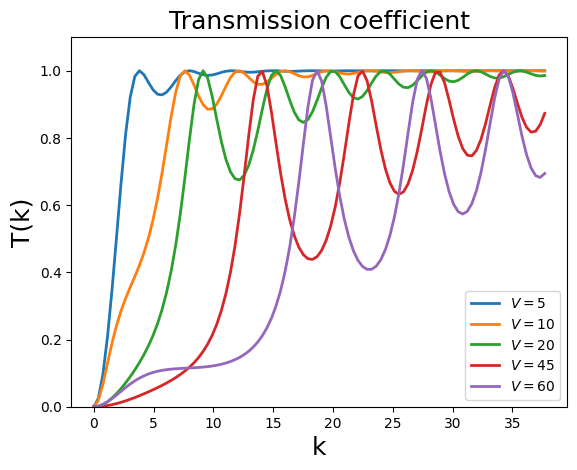

In [ ]:
def tt(k,v0):
    q=np.sqrt(k**2 + v0**2)
    x=4*k**2*q**2
    y=(k**4*np.sin(q)**2 - 2*k**2*q**2*np.sin(q)**2 + 4*k**2*q**2 + q**4*np.sin(q)**2)
    return x/y
#
k_x=np.linspace(1e-4,12*np.pi,num=100,endpoint=True)
# Silly example data
# Make the plot
for y in (5,10,20,45,60):
    plt.plot(k_x, tt(k_x,y), linewidth=2,
#          color="blue",
             label=r"$V = $"+str(y))
plt.xlabel(r"k",size=18)
plt.ylabel(r"T(k)",size=18)
plt.title(r"Transmission coefficient",size=18)
# plt.xlim(0, 2*np.pi)
plt.ylim(0., 1.1)
plt.legend(loc="lower right")
plt.show()

При збільшені $k$, значення $T$, швидко виходить на одиницю - класичну границю для амплітуди розсіяння. Тим не менше помітні осциляції (особливо при збільшені $k_0$)  - прояв хвильової природи руху квантових частинок, які навіть у випадку $E>0$ може відбитись від бар'єру (мінімуми прозорості).
Відмітимо, що якщо:
\begin{equation}\label{proz}
  q\,l = \pi \, n\,,\,\,\,\,\, n = 1,2,\ldots\,, \Rightarrow D = (-1)^n\, e^{-i\,k\,l}
\end{equation}
$a=0$ і відповідно $T =|d|^2=1$, тобто при виконанні співвідношення \eqref{proz} бар'єр є прозорим (резонансна прозорість). Це можна інтерпретувати як результат повного зникнення хвиль віддзеркалених від стрибків потенціалу завдяки інтерференції. Це фактична 1-вимірний варіант ефекту Рамзауера.

__Задача__ Обчисліть спектр стаціонарних станів (розсіяння) частинки в полі прямокутного потенціального барєру висоти $V_0$.

Розглянемо розсіяння на потенціальному бар'єрі $V_0>0$ якщо $E<V_0$. За законами класичної механіки частинка з такою енергією повинна відбитися від бар'єру. В квантовій механіці завдяки відсутності поняття траєкторії і прояву хвильових властивостей така частинка може бути зареєстрована поза барєром - це т.з. тунельний ефект. Враховуючи дану ситуацією запишемо відповідний розвязок р.Ш.:
$$
\psi(x) = \left\{\begin{array}{lll}
  \exp(ikx)+a\exp(-ikx)\,,&\,\, x \le 0\,,&k^2=\frac{2\,m\,E}{\hbar^2}\\
  a\,\exp(qx)+c\,\exp(-qx)\,,&\,\, x \in
  [0,l]\,,&q^2=k_0^2-k^2\,,\,\,k_0^2 = \frac{2\,m\,V_0}{\hbar^2}\\
  d\,\exp(ikx)&\,\, x \ge l&
\end{array}\right.
$$

In [ ]:
psi1t= exp(I*k*x)+a1*exp(-I*k*x)
psi2t= a21*exp(q*x)+a22*exp(-q*x)
psi3t= a3*exp(I*k*x)
coefft=[a1,a21,a22,a3]
syseqt=[(psi1t-psi2t).subs(x,0),diff((psi1t-psi2t),x).subs(x,0),
       (psi2t-psi3t).subs(x,l),diff((psi2t-psi3t),x).subs(x,l)]

Як і вище отримаємо розвязок для коефіцієнтів:

In [ ]:
solutt,=linsolve(syseqt,coefft) # "," means seqence unpacking
solutt

(-k**2*exp(2*l*q)/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2) + k**2/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2) - q**2*exp(2*l*q)/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2) + q**2/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2), 2*k**2/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2) - 2*I*k*q/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2), -2*k**2*exp(2*l*q)/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2) - 2*I*k*q*exp(2*l*q)/(-k**2*exp(2*l*q) + k**2 - 2*I*k*q*exp(2*l*q) - 2*I*k*q + q**2*exp(2*l*q) - q**2), -4*I*k*q*exp(l*q)/(-k**2*exp(2*l*q)*exp(I*k*l) + k**2*exp(I*k*l) - 2*I*k*q*exp(2*l*q)*exp(I*k*l) - 2*I*k*q*exp(I*k*l) + q**2*exp(2*l*q)*exp(I*k*l) - q**2*exp(I*k*l)))

Закон збереження числа частинок (ймовірності):
$$
|a|^2+|d|^2=1\,,
$$

In [ ]:
simplify(solutt[0]*conjugate(solutt[0])+solutt[3]*conjugate(solutt[3]))==1

True

Коефіцієнт прозорості $D = |d|^2$:

In [ ]:
dt=(simplify(conjugate(solutt[3])*solutt[3]))
dt

16*k**2*q**2*exp(2*l*q)/(k**4*exp(4*l*q) - 2*k**4*exp(2*l*q) + k**4 + 2*k**2*q**2*exp(4*l*q) + 12*k**2*q**2*exp(2*l*q) + 2*k**2*q**2 + q**4*exp(4*l*q) - 2*q**4*exp(2*l*q) + q**4)

Для спрощення виразу будемо вважати, що $q\,l>>1$, тоді головним доданком є

In [ ]:
dt0=((dt.subs(exp(q*a),x)).series(x,0,4))
dt0

16*k**2*q**2*exp(2*l*q)/(k**4*exp(4*l*q) - 2*k**4*exp(2*l*q) + k**4 + 2*k**2*q**2*exp(4*l*q) + 12*k**2*q**2*exp(2*l*q) + 2*k**2*q**2 + q**4*exp(4*l*q) - 2*q**4*exp(2*l*q) + q**4)

In [ ]:
dt0.removeO().subs(x,exp(-q*l))

16*k**2*q**2*exp(2*l*q)/(k**4*exp(4*l*q) - 2*k**4*exp(2*l*q) + k**4 + 2*k**2*q**2*exp(4*l*q) + 12*k**2*q**2*exp(2*l*q) + 2*k**2*q**2 + q**4*exp(4*l*q) - 2*q**4*exp(2*l*q) + q**4)

$$D = \left(4\frac{k\,q}{k^2+q^2}\right)^2\,e^{-2\,q\,l}$$

Цей результат можна узагальнити на випадок бар'єру довільної форми за умови повільної зміни потенціальної енергії так що можна апроксимувати таку функцію як набір прямокутних бар'єрів.
<!--  -->
<img src="./figs/fig_barrier.png" alt="Image" width="400">

Тоді прозорість дорівнює добутку прозорості окремих можна записати для прозорості остаточно:
$$D = D_0\,\exp\left(-\frac{2}{\hbar}\,\int\limits^{x_2}_{x_1}\sqrt{2\,m(U(x)-E)}\,dx\right)$$
<!--  -->
Завдяки тунельному ефекту ми спостерігаємо такі явища як [природний радіоактивний $\alpha$-розпад](https://en.wikipedia.org/wiki/Alpha_decay) та явище холодної (тобто не спричиненої значною температурою) емісіі електронів з поверхні металу під дією електростатичного поля $\mathcal{E}$. В рамках класичної механіки, неможливо пояснити це явище, оскільки поле в метал не проникає. Якщо вважати що електрони утримуються у металі ефективною потенціальною ямою (притягнення до іонів кристалічної гратки), то з квантовомеханічної точки зору вихід електронів можливий завдяки пониженню потенціалу назовні і тунелюванню електронів крізь відповідний бар'єр (див рис.).
<!--  -->
<img src="./figs/fig_coldemiss.png" alt="Image" width="300">

В рамках такої простої моделі можна отримати залежність відповідного тунельного струму від напруженності поля $\mathcal{E}$ оскільки $I \sim D$. Дійсно, згідно з виразом
<!--  -->
$$I = I_0\,\exp{\left(-\frac{2}{\hbar}\,\int\limits^{x_{E}}_{0}\sqrt{2\,m(E_0-\mathcal{E}\,x-E)}\,dx\right)} = I_0\,\exp{\left(-\frac{\mathcal{E}_0}{\mathcal{E}}\right)}$$

Тунельний ефект лежить в основі роботи [скануючого тунельного мікроскопу](https://en.wikipedia.org/wiki/Scanning_tunneling_microscope).

Аналогічно, $\alpha$-розпад можна представити ([Георгій Гамов])(https://en.wikipedia.org/wiki/George_Gamow) як тунелювання $\alpha$-частинки з ядра крізь кулонівський бар'єр. Основною величиною, що спостерігається на ескперименті є період полурозпада - швидкість зміни долі ядер що розпадаються:
$$\frac{dN}{N} = -\lambda\, dt \Rightarrow N(t) = N_0\, e^{-\lambda\,t}.$$
Очевидно, що $\lambda \sim D$:
$$\lambda = D/t_0$$
де $t_0$ - певний характерний час, що повязаний із енергією $\alpha$-частинки та розміром ядра $t_0\sim r_0/v_0$. Обчислимо $D$:
<!--  -->
<img src="./figs/fig_alphadecay.png" alt="Image" width="400">
<!--  -->
$$D = D_0\,\exp{\left(-\frac{2}{\hbar}\,\int\limits^{r_E}_{0}\sqrt{2\,m_{\alpha}(2Ze^2/r-E)}\,dr\right)} =
D_0\,\exp{\left(-\frac{2\,r_E}{\hbar}\sqrt{2\,m_{\alpha}\,E}\,\int\limits^{1}_{0}\sqrt{1/x-1}\,dx\right)}\\
r_E = 2Ze^2/E
$$
$$\lambda = \lambda_0\exp{\left(-2\pi\,Ze^2\,\sqrt{\frac{2m_{\alpha}}{E}}\right)}$$

In [ ]:
integrate(sqrt(1/x-1),(x,0,1))

pi/2

Цей результат дозволяє зробити висновок про залежність логарифма $\lambda$ від різниці енергій $\alpha$ частинок для сімейства ядер які утворюються при послідовному $\alpha$-розпаді (наприклад  ${\rm Th}\to {\rm Ra} \to {\rm Rn} \to {\rm Po}$):
$$\ln{\lambda} = A+B/\sqrt{E} =a + b\,\Delta E\,, \,\,\, E = E_0+\Delta E\,,\,\,\,\Delta E \ll E_0$$ Таке співвідношеня надає пояснення експериментальному закону [Гейгера-Наттола](https://en.wikipedia.org/wiki/Geiger%E2%80%93Nuttall_law).

## Задачі для самостійної роботи
***

__Задача__ Визначте стаціонарні стани розсіяння для частинки у полі потенціальной сходинки:
$$V(x) = V_0\,\theta(x)\,,$$ де $\theta(x)$ - функція Хевісайда: $\theta(x) = 1\,,$ якщо $x
\ge 0$ и $\theta(x) = 0\,,$ якщо $x < 0$. Перевірте закон збереження ймовірності.
***
__Задача__  Розв'яжіть задачу розсіяння частинки на прямокутному потенціальному бар'єрі:

$$V(x) = \left\{\begin{array}{rl}
V_0\,,&\,\, |\,x-l/2|\le l/2 \\
  0\,,&\,\, |\,x-l/2|\ge l/2
\end{array}\right.$$
у випадку $E>V_0$. Перевірте закон збереження ймовірності.

__Задача__ Обчисліть залежність струму холодної емісії $I(\mathcal{E})$ на основі простої моделі потенціального бар'єру вище. Оцініть відповідне значення поля припускаючи, що глибина потенціальної ями для електронів в металі порядка $1 \, {\rm eV}$.
***